In [4]:
pip install tf-keras



   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------ --------- 1.3/1.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.7 MB/s eta 0:00:00


In [ ]:
from transformers import BertTokenizer, TFBertForSequenceClassification



In [2]:
#IMPORT REQUIRED LIBRARIES

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report,roc_auc_score,confusion_matrix,roc_curve
import json
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

#Warnings
import warnings
warnings.filterwarnings("ignore") 

In [6]:
#FEATURE EXTRACTION

#LOAD PROCESSED DATASET

df = pd.read_csv(r"C:\Users\Muthu\processed_reviews.csv")

In [8]:
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,text,sentiment
0,2025-02-15,Impressive,Mother former community upon vote fact. Sure s...,2,ybass,68,78,Mobile,es,Canada,3.0,No,{'sentences': ['Mother former community upon v...,Positive
1,2024-10-16,Waste of Time,General paper understand main. Or age half won...,5,glenn33,71,193,Web,de,India,4.1,Yes,{'sentences': ['General paper understand main....,Positive
2,2024-10-16,Waste of Time,Here situation his high stage. Agree certainly...,4,debbie27,66,184,Web,hi,India,4.1,Yes,{'sentences': ['Here situation his high stage....,Positive
3,2024-12-21,Not Accurate,Rule court behind growth reality. Tonight whos...,1,hannahrussell,5,193,Web,fr,Canada,4.0,Yes,{'sentences': ['Rule court behind growth reali...,Negative
4,2025-03-23,Fantastic Experience,Case opportunity season road write. Effort gre...,3,cnorton,71,131,Web,hi,Australia,4.1,No,{'sentences': ['Case opportunity season road w...,Positive


In [10]:
#extract the string from the dictionary.
df['lemmatized_words'] = df['text'].apply(lambda x: json.loads(x.replace("'", "\""))['lemmatized_words'])
# Convert lists of words to strings
df['lemmatized_sentences'] = df['lemmatized_words'].apply(lambda x: " ".join(x))

In [12]:
#FEATURE EXTRACTION
import pickle
x_train, x_test, y_train, y_test = train_test_split(df['lemmatized_sentences'], df['sentiment'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
x_train_vectors = vectorizer.fit_transform(x_train)
x_test_vectors = vectorizer.transform(x_test)

with open("tfidfvectorizer.pkl","wb") as file:
    pickle.dump(vectorizer,file)

print("vectorizer pickle saved sucessfully")

vectorizer pickle saved sucessfully


In [14]:
# Encode sentiment labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df["sentiment_encoded"] = label_encoder.fit_transform(df["sentiment"])

In [16]:
#OVER SAMPLING

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
x_train_resampled, y_train_resampled = ros.fit_resample(x_train_vectors, y_train)

In [18]:
#MODEL TRAIN AND PREDICTION

#NAIVE BAYES

# Define parameter grid
param_grid = {
    'alpha': np.logspace(-2, 1, 20)  # Alpha values from 0.01 to 10
}
model = MultinomialNB()

model.fit(x_train_resampled, y_train_resampled)

y_pred= model.predict(x_test_vectors)
y_pred_probability= model.predict_proba(x_test_vectors)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))
print(f"Roc_Auc score:{roc_auc_score(y_test,y_pred_probability,multi_class='ovr')}")

              precision    recall  f1-score   support

    Negative       0.68      0.82      0.75       450
     Neutral       0.59      0.76      0.66       192
    Positive       0.95      0.85      0.89      1358

    accuracy                           0.83      2000
   macro avg       0.74      0.81      0.77      2000
weighted avg       0.85      0.83      0.84      2000

[[ 370   29   51]
 [  35  145   12]
 [ 137   72 1149]]
Roc_Auc score:0.9222166029923994


In [20]:
#SUPPORT VECTOR CLASSIFIER

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.preprocessing import label_binarize

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)

# Create a dictionary with correct class labels
class_weight_dict = {cls: weight for cls, weight in zip(np.unique(y_train_resampled), class_weights)}

model_svm = SVC(kernel='linear',C=1,probability=True,class_weight=class_weight_dict)
model_svm.fit(x_train_resampled, y_train_resampled)

y_pred_svm = model_svm.predict(x_test_vectors)
y_pred_probability = model_svm.predict_proba(x_test_vectors)

print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test,y_pred_svm))

print(f"Roc_Auc score:{roc_auc_score(y_test,y_pred_probability,multi_class='ovr')}")




              precision    recall  f1-score   support

    Negative       0.76      0.89      0.82       450
     Neutral       0.55      0.84      0.67       192
    Positive       0.97      0.84      0.90      1358

    accuracy                           0.85      2000
   macro avg       0.76      0.86      0.80      2000
weighted avg       0.88      0.85      0.86      2000

[[ 401   31   18]
 [  18  162   12]
 [ 111  102 1145]]
Roc_Auc score:0.9635394751780835


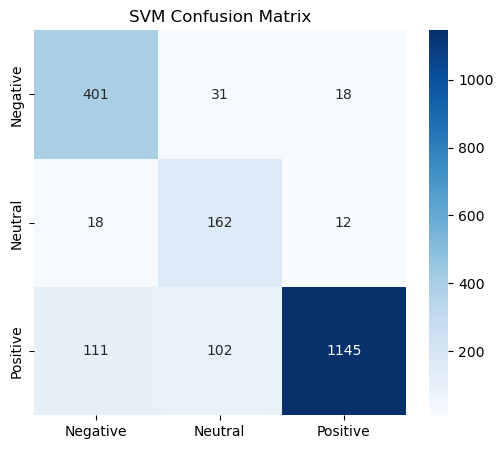

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# --- 1. Confusion Matrix Heatmap ---
conf_matrix = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("SVM Confusion Matrix")
plt.show() # It's a good practice to explicitly show the plot

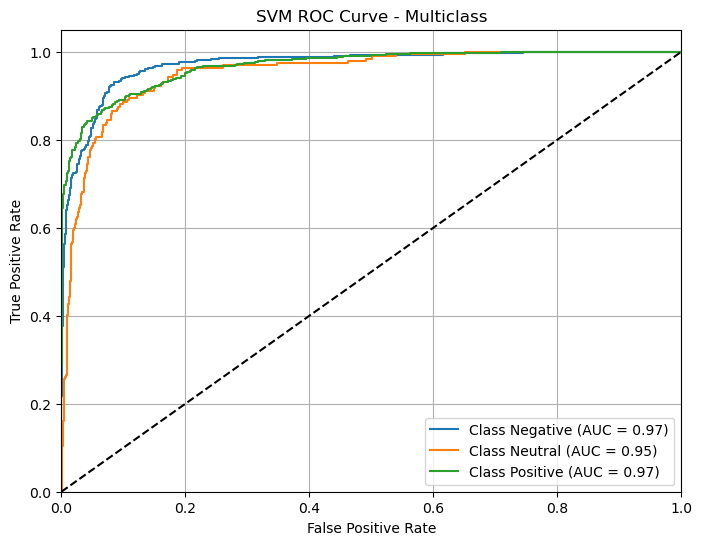

In [28]:
# --- 2. ROC Curve for Multiclass (One-vs-Rest) ---
# Binarize the output
from sklearn.metrics import auc

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = y_pred_probability

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve - Multiclass")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [30]:
#Random Forest Classifier
model_rf = RandomForestClassifier(max_depth=2)
model_rf.fit(x_train_resampled,y_train_resampled)

y_pred_rf = model_rf.predict(x_test_vectors)
y_pred_proba = model_rf.predict_proba(x_test_vectors)
print(accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))
print(f"Roc_Auc Score :{roc_auc_score(y_test,y_pred_proba,multi_class='ovr')}")

0.616
              precision    recall  f1-score   support

    Negative       0.69      0.70      0.70       450
     Neutral       0.23      0.96      0.38       192
    Positive       0.97      0.54      0.69      1358

    accuracy                           0.62      2000
   macro avg       0.63      0.73      0.59      2000
weighted avg       0.84      0.62      0.66      2000

[[316 114  20]
 [  6 185   1]
 [137 490 731]]
Roc_Auc Score :0.8968716023943282


In [32]:
pip install tensorflow

In [34]:
#LONG SHORT TERM MEMORY
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define LSTM model
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=x_train_resampled.shape[1]),  # Word embedding
    LSTM(128, return_sequences=True),  # First LSTM layer
    LSTM(64),  # Second LSTM layer
    Dropout(0.5),  # Dropout to prevent overfitting
    Dense(3, activation='softmax')  # ✅ Output layer for 3-class classification
])

# Compile model ✅ Corrected loss function for multiclass
model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Convert sparse matrix to dense array before padding
x_train_dense = x_train_resampled.toarray()
x_test_dense = x_test_vectors.toarray()

# Padding sequences
x_train_padded = pad_sequences(x_train_dense, maxlen=100, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test_dense, maxlen=100, padding='post', truncating='post')
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform labels
y_train_encoded = label_encoder.fit_transform(y_train_resampled)  # Converts 'Positive', 'Negative', 'Neutral' to 0,1,2
y_test_encoded = label_encoder.transform(y_test)  # Ensure test labels follow the same mapping

# Convert to NumPy arrays
y_train_resampled = np.array(y_train_encoded, dtype=np.int32)
y_test = np.array(y_test_encoded, dtype=np.int32)

# Convert labels to NumPy array ✅ Ensure correct data type
y_train_resampled = np.array(y_train_resampled, dtype=np.int32)  # Labels should be integers: 0, 1, 2
y_test = np.array(y_test, dtype=np.int32)

# Train the model ✅ Use padded test data
model_lstm.fit(x_train_padded, y_train_resampled, epochs=5, batch_size=16, validation_data=(x_test_padded, y_test))

# Predictions
y_pred_prob = model_lstm.predict(x_test_padded)  # Probabilities
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels

# Evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob, multi_class='ovr'))

Epoch 1/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 145s 138ms/step - accuracy: 0.3272 - loss: 1.1016 - val_accuracy: 0.6790 - val_loss: 1.0794
Epoch 2/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 142s 141ms/step - accuracy: 0.3297 - loss: 1.1000 - val_accuracy: 0.2250 - val_loss: 1.1102
Epoch 3/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 128s 128ms/step - accuracy: 0.3276 - loss: 1.0996 - val_accuracy: 0.2250 - val_loss: 1.0970
Epoch 4/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 124s 123ms/step - accuracy: 0.3410 - loss: 1.0992 - val_accuracy: 0.6790 - val_loss: 1.0775
Epoch 5/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 135s 135ms/step - accuracy: 0.3323 - loss: 1.0993 - val_accuracy: 0.6790 - val_loss: 1.0940
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       450
           1       0.00      0.00      0.00       192
           2       0.68      1.00      0.81      1358

    accuracy                           0.68      2000
   macro avg       0.23

In [36]:
# SIMPLE RNN CLASSIFIER

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define LSTM model
model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=x_train_resampled.shape[1]),  # Word embedding
    SimpleRNN(128, return_sequences=True),  # First LSTM layer
    SimpleRNN(64),  # Second LSTM layer
    Dropout(0.5),  # Dropout to prevent overfitting
    Dense(3, activation='softmax')  # ✅ Output layer for 3-class classification
])

# Compile model ✅ Corrected loss function for multiclass
model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Convert sparse matrix to dense array before padding
x_train_dense = x_train_resampled.toarray()
x_test_dense = x_test_vectors.toarray()

# Padding sequences
x_train_padded = pad_sequences(x_train_dense, maxlen=100, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test_dense, maxlen=100, padding='post', truncating='post')

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform labels
y_train_encoded = label_encoder.fit_transform(y_train_resampled)  # Converts 'Positive', 'Negative', 'Neutral' to 0,1,2
y_test_encoded = label_encoder.transform(y_test)  # Ensure test labels follow the same mapping

# Convert to NumPy arrays
y_train_resampled = np.array(y_train_encoded, dtype=np.int32)
y_test = np.array(y_test_encoded, dtype=np.int32)

# Convert labels to NumPy array ✅ Ensure correct data type
y_train_resampled = np.array(y_train_resampled, dtype=np.int32)  # Labels should be integers: 0, 1, 2
y_test = np.array(y_test, dtype=np.int32)

# Train the model ✅ Use padded test data
model_lstm.fit(x_train_padded, y_train_resampled, epochs=5, batch_size=16, validation_data=(x_test_padded, y_test))

# Predictions
y_pred_prob = model_lstm.predict(x_test_padded)  # Probabilities
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels

# Evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob, multi_class='ovr'))

Epoch 1/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 67s 61ms/step - accuracy: 0.3337 - loss: 1.2427 - val_accuracy: 0.0960 - val_loss: 1.1099
Epoch 2/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - accuracy: 0.3285 - loss: 1.1188 - val_accuracy: 0.0960 - val_loss: 1.1350
Epoch 3/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.3309 - loss: 1.1050 - val_accuracy: 0.6790 - val_loss: 1.0767
Epoch 4/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 68s 68ms/step - accuracy: 0.3317 - loss: 1.1024 - val_accuracy: 0.2250 - val_loss: 1.0923
Epoch 5/5
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 56s 56ms/step - accuracy: 0.3277 - loss: 1.1019 - val_accuracy: 0.0960 - val_loss: 1.1394
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       450
           1       0.10      1.00      0.18       192
           2       0.00      0.00      0.00      1358

    accuracy                           0.10      2000
   macro avg       0.03      0.33

In [38]:
#GENERATE PICKLE MODEL

with open("best_sentimental_model.pkl","wb") as file:
    pickle.dump(model_svm,file)

print("pickle file saved Successfully!")

pickle file saved Successfully!


In [40]:
#GENERATE VECTORISER AS PICKLE FILE

with open("tf_idf_vectoriser.pkl","wb") as file:
    pickle.dump(vectorizer,file)
print("pickle file saved Successfully!")

pickle file saved Successfully!
